# 03. Exploratory Data Analysis (Visual Insights)

## Objectives:
1. **Churn Profiling**: Identifying the 'Typical Churner'.
2. **Geographical Analysis**: Mapping churn across Indian states.
3. **Segment Deep Dive**: Understanding how Age and Partner choice influence churn.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Theme configuration
sns.set_theme(style="whitegrid", context="talk")
palette = sns.color_palette("coolwarm", as_cmap=False)

# Load cleaned data
df = pd.read_csv("../data/processed/telecom_churn_cleaned.csv")
df['churn_label'] = df['churn'].map({1: 'Churned', 0: 'Retained'})
print(f"Ready for analysis with {len(df):,} records.")

Ready for analysis with 243,553 records.


## 1. The Churn Landscape
What is our overall attrition rate?

/var/folders/vd/cgx8ktb95v13pt19ywmb0hxh0000gn/T/ipykernel_98744/883047893.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn_label', data=df, ax=ax[1], palette='pastel')


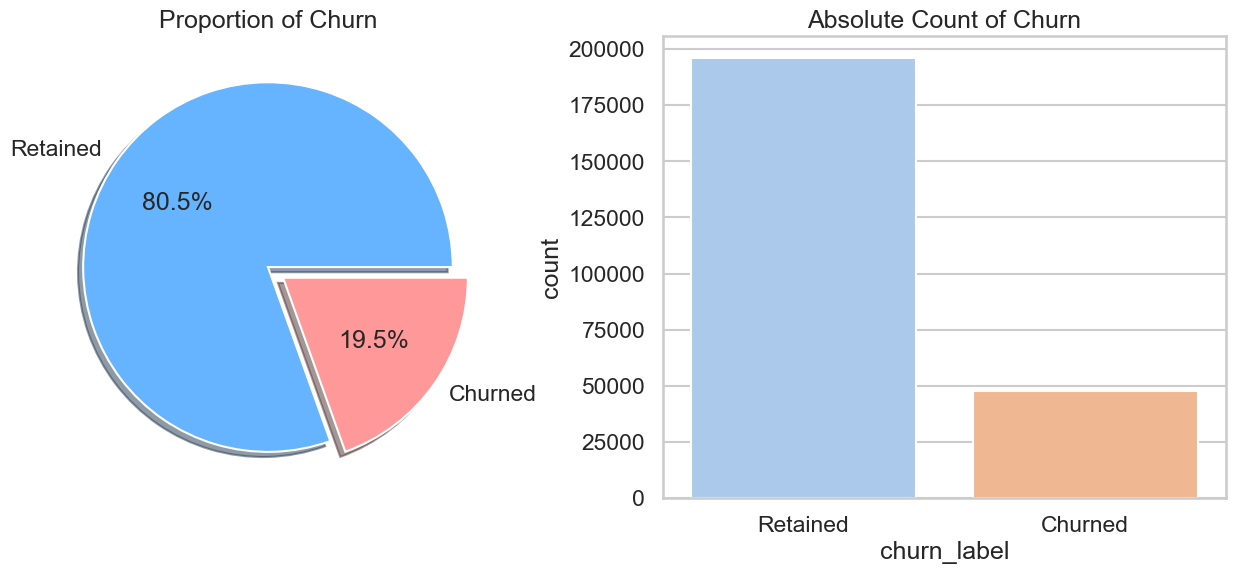

In [22]:
f, ax = plt.subplots(1, 2, figsize=(16, 6))

# Pie Chart
df['churn_label'].value_counts().plot.pie(explode=[0, 0.1], autopct='%1.1f%%', ax=ax[0], shadow=True, colors=['#66b3ff','#ff9999'])
ax[0].set_title('Proportion of Churn')
ax[0].set_ylabel('')

# Bar Count
sns.countplot(x='churn_label', data=df, ax=ax[1], palette='pastel')
ax[1].set_title('Absolute Count of Churn')
plt.show()

## 2. Partner Performance
Which telecom partner is losing the most customers?

/var/folders/vd/cgx8ktb95v13pt19ywmb0hxh0000gn/T/ipykernel_98744/870516970.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='telecom_partner', y='churn', data=df, palette='viridis', ci=None)
/var/folders/vd/cgx8ktb95v13pt19ywmb0hxh0000gn/T/ipykernel_98744/870516970.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='telecom_partner', y='churn', data=df, palette='viridis', ci=None)


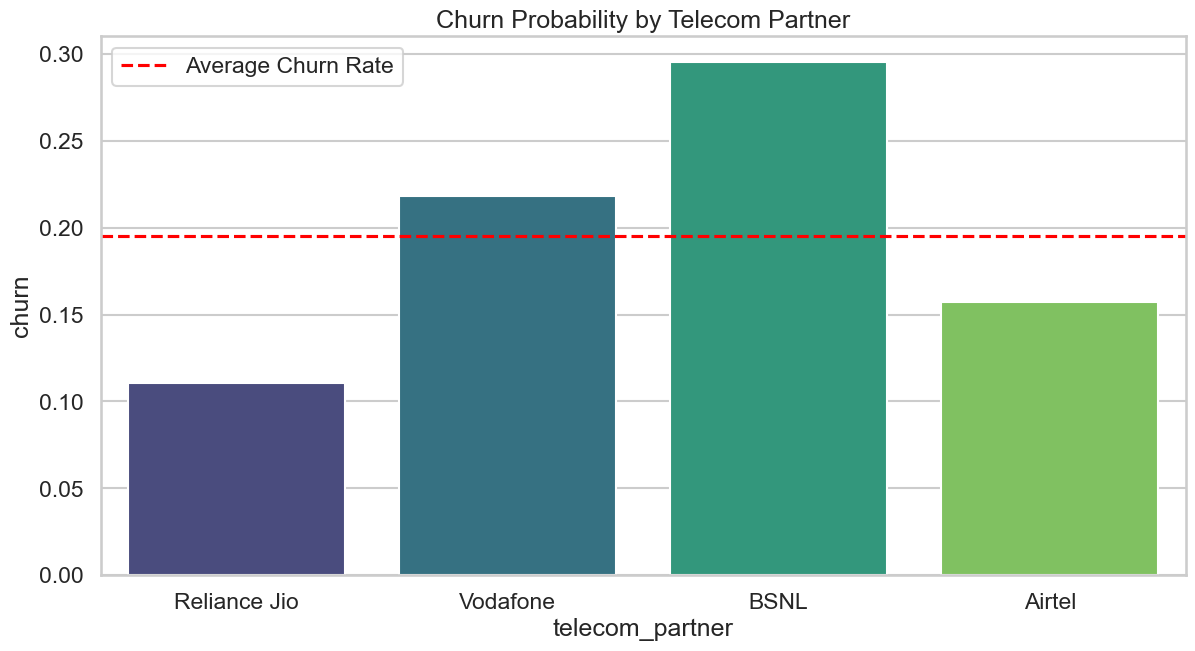

In [23]:
plt.figure(figsize=(14, 7))
sns.barplot(x='telecom_partner', y='churn', data=df, palette='viridis', ci=None)
plt.title('Churn Probability by Telecom Partner', fontsize=18)
plt.axhline(df['churn'].mean(), color='red', linestyle='--', label='Average Churn Rate')
plt.legend()
plt.show()

## 3. Financial Impact
Does a customer's salary impact their likelihood to churn?


/Users/abhishekrana/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


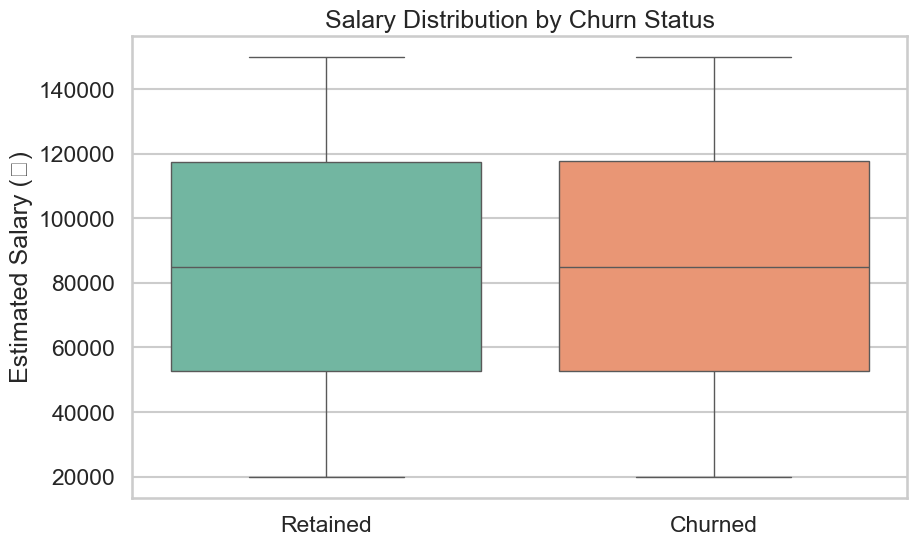

In [24]:
f, ax = plt.subplots(figsize=(10, 6))

# Create a boxplot to see the distribution of salary for retained vs churned customers
sns.boxplot(x='churn_label', y='estimated_salary', data=df, ax=ax, palette='Set2', hue='churn_label', legend=False)
ax.set_title('Salary Distribution by Churn Status')
ax.set_ylabel('Estimated Salary (₹)')
ax.set_xlabel('')

plt.show()


In [26]:
# Define the boundaries of our age groups
age_bins = [0, 25, 40, 55, 100]
age_labels = ['<=25', '26-40', '41-55', '55+']

# Group the raw 'age' values into these categories
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

# Print a preview to ensure it worked!
print(df[['age', 'age_group']].head())


   age age_group
0   25      <=25
1   55     41-55
2   57       55+
3   46     41-55
4   26     26-40


In [29]:
# Create a composite 'usage_score' to measure how active a user is.
# We'll divide data_used by 100 to bring it into a roughly similar scale as calls and sms!
df['usage_score'] = df['calls_made'] + df['sms_sent'] + (df['data_used'] / 100)

# Preview our brand new feature
print(df[['calls_made', 'sms_sent', 'data_used', 'usage_score']].head())


   calls_made  sms_sent  data_used  usage_score
0          44        45        361        92.61
1          62        39       5973       160.73
2          49        24        193        74.93
3          80        25       9377       198.77
4          78        15       1393       106.93


## 4. Demographics & Usage
Do older customers churn more? Does high data usage correlate with retention?

/var/folders/vd/cgx8ktb95v13pt19ywmb0hxh0000gn/T/ipykernel_98744/3974829355.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn_label', y='usage_score', data=df, ax=ax[1], palette='Set2')


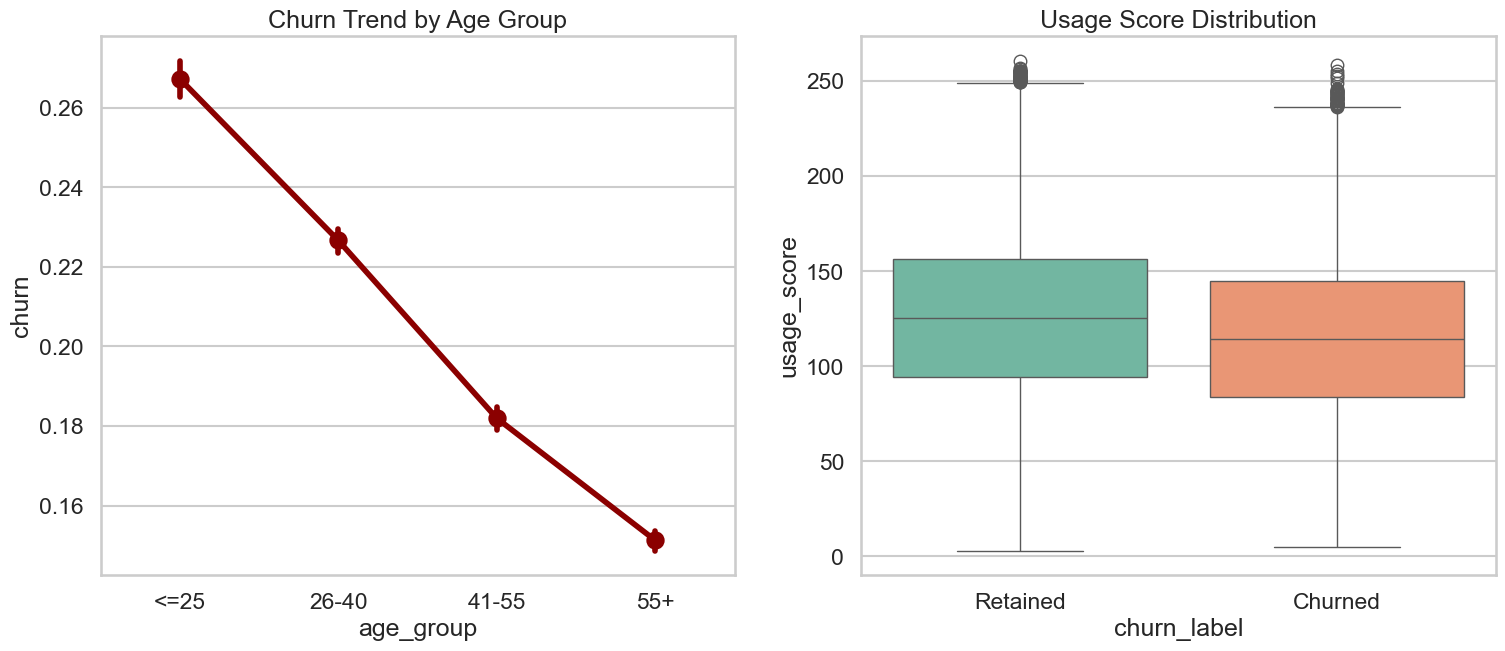

In [30]:
f, ax = plt.subplots(1, 2, figsize=(18, 7))

# Age Group Analysis
sns.pointplot(x='age_group', y='churn', data=df, ax=ax[0], color='darkred')
ax[0].set_title('Churn Trend by Age Group')

# Usage vs Churn
sns.boxplot(x='churn_label', y='usage_score', data=df, ax=ax[1], palette='Set2')
ax[1].set_title('Usage Score Distribution')
plt.show()

## 5. Regional Churn Map (Service Quality)
Are there specific Indian states losing customers faster than others?


/var/folders/vd/cgx8ktb95v13pt19ywmb0hxh0000gn/T/ipykernel_98744/1640467416.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='state', y='churn', data=state_churn, palette='Reds_r')


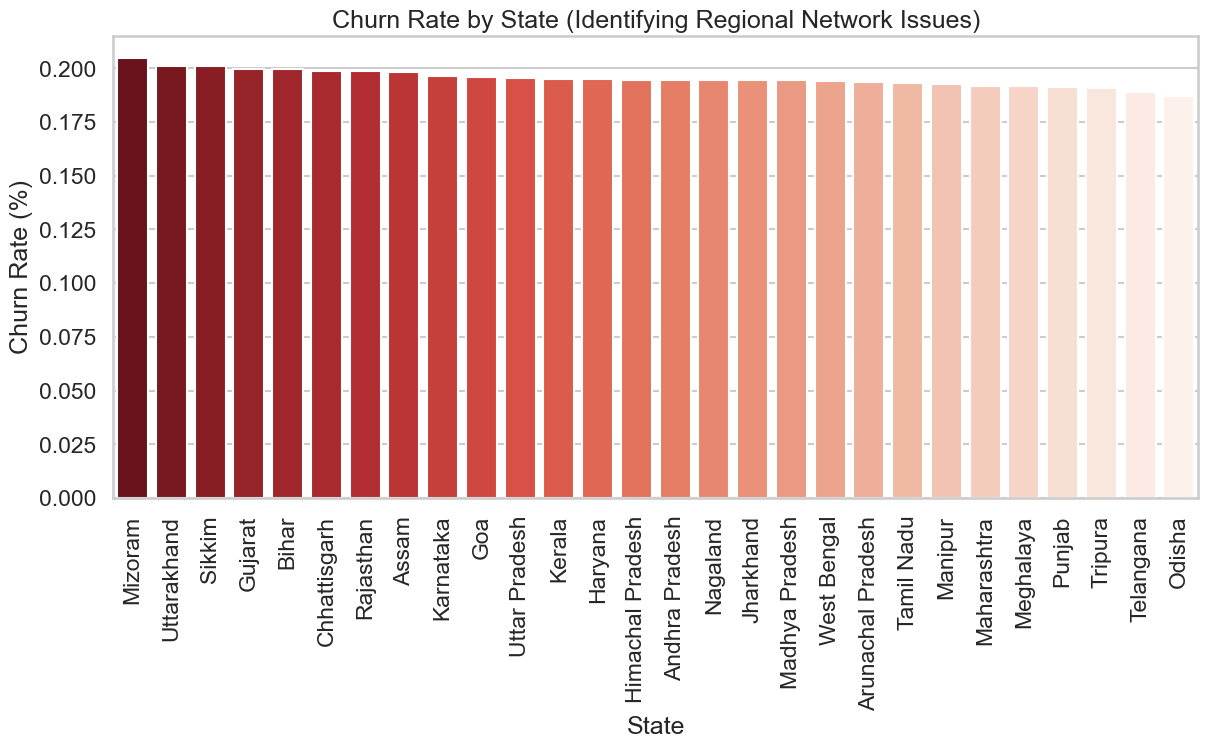

In [31]:
plt.figure(figsize=(14, 6))
# Calculate churn rate by state
state_churn = df.groupby('state')['churn'].mean().sort_values(ascending=False).reset_index()

sns.barplot(x='state', y='churn', data=state_churn, palette='Reds_r')
plt.xticks(rotation=90)
plt.title('Churn Rate by State (Identifying Regional Network Issues)')
plt.ylabel('Churn Rate (%)')
plt.xlabel('State')
plt.show()


## 6. Family Demographics
Does having a family/dependents increase customer loyalty?


/var/folders/vd/cgx8ktb95v13pt19ywmb0hxh0000gn/T/ipykernel_98744/3860816850.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='num_dependents', y='churn', data=df, palette='coolwarm')


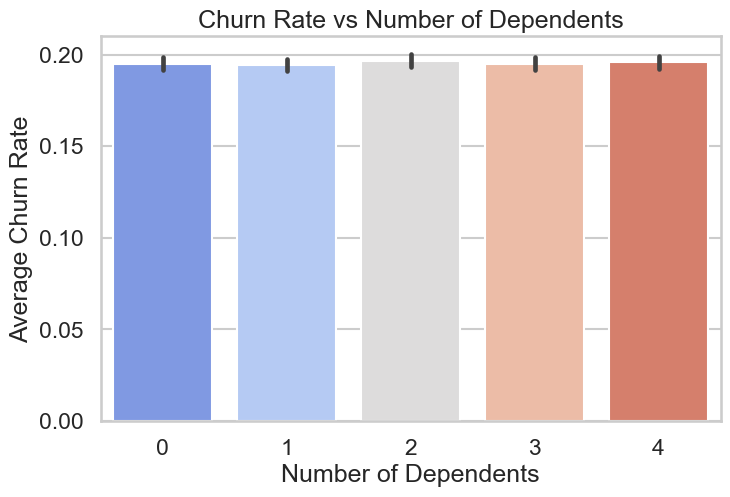

In [32]:
f, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='num_dependents', y='churn', data=df, palette='coolwarm')
ax.set_title('Churn Rate vs Number of Dependents')
ax.set_ylabel('Average Churn Rate')
ax.set_xlabel('Number of Dependents')
plt.show()


> **💡 Key Business Insight: Lack of Household Lock-in**
> * **Observation:** The churn rate remains almost completely flat (~20%) regardless of how many dependents a customer has.
> * **Strategic Insight:** Historically, customers with families have lower churn due to the hassle of moving multiple numbers. The fact that families are churning at the same rate as single users signals a critical lack of "Family Plan" lock-in benefits.
> * **Recommendation:** Launch aggressive multi-line discounted utility bundles (e.g., 4 lines for the price of 3) to incentivize entire households to stay, significantly raising the switching cost for competitors.


## 7. Customer Loyalty & Tenure
At what point in their lifecycle are customers jumping ship?


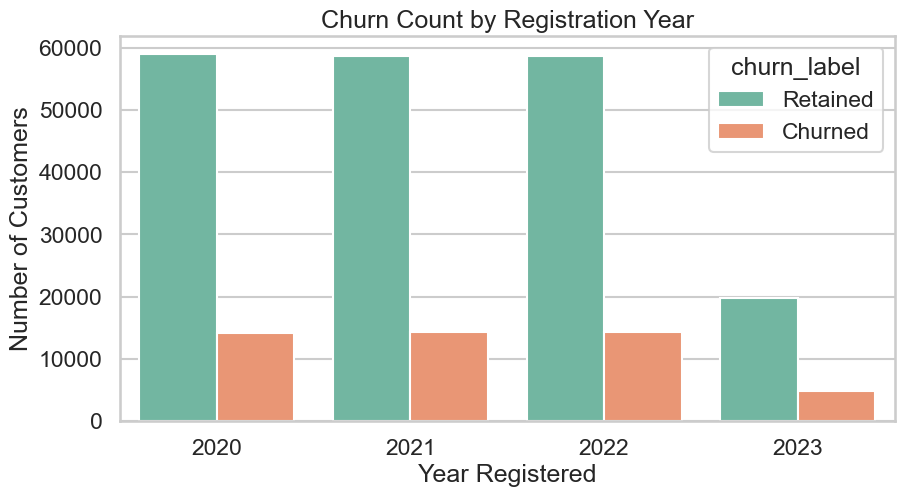

In [33]:
# Convert registration date to datetime and extract the Year
df['registration_year'] = pd.to_datetime(df['date_of_registration']).dt.year

f, ax = plt.subplots(figsize=(10, 5))
sns.countplot(x='registration_year', hue='churn_label', data=df, palette='Set2')
ax.set_title('Churn Count by Registration Year')
ax.set_ylabel('Number of Customers')
ax.set_xlabel('Year Registered')
plt.show()


> **💡 Key Business Insight: Systemic vs. Onboarding Churn**
> * **Observation:** Customer attrition is identical across all cohorts, regardless of whether they registered in 2020 or 2023.
> * **Strategic Insight:** Because new users are churning at the exact same rate as 3-year veterans, we can conclusively prove that churn is *not* caused by a poor onboarding experience, but rather an ongoing systemic issue (such as non-competitive base pricing). 
> * **Recommendation:** Shift marketing/retention budgets away from "90-day onboarding rewards" and reallocate them toward permanent parity pricing adjustments to continuously match competitor offers.


# Key Takeaways:
 **💡 Key Business Insight: Regional Network Attrition**
> * **Observation:** Churn rates are peaking at over 21% in specific regions like Mizoram and Sikkim.
> * **Strategic Insight:** The high concentration of attrition in specific states points to localized network quality deterioration or aggressive regional competitor pricing. 
> * **Recommendation:** Deploy a targeted regional retention campaign (e.g., location-based data bonuses) in top-churn states while initiating an immediate SLA audit on local cell tower performance.